# 00. Master Dataset Preparation

This notebook documents the construction of `ai_market_master_dataset.csv` — the single merged dataset used in all subsequent analysis notebooks (EDA, Hypothesis Testing, Event Study, ML).

## Why this notebook exists

The two raw data sources operate on **incompatible time grids**:

| Source | Time grid | Coverage |
|--------|-----------|----------|
| `botz_daily_data.csv` | **Trading days only** (Mon–Fri, no market holidays) | Sep 2016 – Dec 2023 |
| `ai_daily_papers.csv` | **All calendar days** (papers submitted on weekends) | 1997 – Dec 2023 |

Naively merging on `date` would cause weekend arXiv submissions to be silently **lost** — they simply have no matching row in the BOTZ trading calendar. This notebook solves that problem with an explicit **accumulation strategy** that rolls weekend and holiday paper counts forward to the next trading day.

## Pipeline
```
Load raw data  →  Align to trading calendar  →  Accumulate non-trading-day papers
→  Merge  →  Validate  →  Save master dataset
```

> **Reproducibility note:** Running this notebook from scratch requires `botz_daily_data.csv` and `ai_daily_papers.csv` (produced by `00_ETFDataAcquisition.ipynb` and `00_PaperDataAcquisition.ipynb` respectively).

## 0. Setup & Configuration

In [21]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Shared constants ──────────────────────────────────────────────────────────
DATE_START   = '2016-09-01'
DATE_END     = '2023-12-31'
OUTPUT_PATH  = 'ai_market_master_dataset.csv'

# ── Colour palette (consistent across all project notebooks) ──────────────────
C_ETF    = '#1f77b4'   # steel blue  → BOTZ price / returns
C_PAPER  = '#ff7f0e'   # orange      → paper counts
C_ACCENT = '#2ca02c'   # green       → positive annotations
C_WARN   = '#d62728'   # red         → warnings / issues

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


## 1. Load Raw Data Sources

We load both raw CSVs and immediately inspect their structure, date ranges, and potential issues before any transformation.

In [22]:
# ── Load BOTZ ETF data ────────────────────────────────────────────────────────
botz = pd.read_csv('botz_daily_data.csv', parse_dates=['date'])
botz = botz.sort_values('date').reset_index(drop=True)

# ── Load arXiv paper counts ───────────────────────────────────────────────────
papers = pd.read_csv('ai_daily_papers.csv', parse_dates=['date'])
papers = papers.sort_values('date').reset_index(drop=True)

# ── Filter papers to project timeframe (with a buffer for accumulation) ───────
# We keep data from slightly before DATE_START to correctly accumulate
# papers that fall on non-trading days before the first trading day.
papers = papers[papers['date'] <= DATE_END].copy()

print('=' * 55)
print('RAW DATA SUMMARY')
print('=' * 55)
print(f'\n[BOTZ ETF]')
print(f'  Rows        : {len(botz):,}')
print(f'  Date range  : {botz.date.min().date()} → {botz.date.max().date()}')
print(f'  Columns     : {botz.columns.tolist()}')
print(f'  Missing vals: {botz.isnull().sum().sum()}')

print(f'\n[arXiv cs.AI Papers]')
print(f'  Rows        : {len(papers):,}')
print(f'  Date range  : {papers.date.min().date()} → {papers.date.max().date()}')
print(f'  Columns     : {papers.columns.tolist()}')
print(f'  Total papers collected : {papers.paper_count.sum():,}')

print(f'\n[Key observation]')
weekday_papers  = (papers['date'].dt.dayofweek < 5).sum()
weekend_papers  = (papers['date'].dt.dayofweek >= 5).sum()
print(f'  arXiv entries on weekdays : {weekday_papers:,}')
print(f'  arXiv entries on weekends : {weekend_papers:,}')
print(f'  → Weekend submissions exist and must not be discarded.')

RAW DATA SUMMARY

[BOTZ ETF]
  Rows        : 1,836
  Date range  : 2016-09-14 → 2023-12-29
  Columns     : ['date', 'price', 'daily_return']
  Missing vals: 0

[arXiv cs.AI Papers]
  Rows        : 2,988
  Date range  : 1997-03-20 → 2023-12-29
  Columns     : ['date', 'paper_count']
  Total papers collected : 62,519

[Key observation]
  arXiv entries on weekdays : 2,186
  arXiv entries on weekends : 802
  → Weekend submissions exist and must not be discarded.


## 2. The Core Problem: Incompatible Time Grids

Researchers submit papers to arXiv **every day of the week**, including weekends and public holidays. Financial markets, however, are closed on weekends and holidays — BOTZ has no price data on those days.

A naive `pd.merge(botz, papers, on='date')` would **silently drop all weekend arXiv submissions**, introducing a systematic downward bias in paper counts for every Monday and post-holiday trading day.

The cell below demonstrates the magnitude of this problem.

In [23]:
# ── Demonstrate what naive merge loses ───────────────────────────────────────
papers_in_window = papers[
    (papers['date'] >= DATE_START) & (papers['date'] <= DATE_END)
].copy()

# Naive merge: only calendar days that match BOTZ trading days
naive_merge = pd.merge(botz, papers_in_window, on='date', how='left')

total_papers_raw    = papers_in_window['paper_count'].sum()
total_papers_naive  = naive_merge['paper_count'].sum()
papers_lost         = total_papers_raw - total_papers_naive
loss_pct            = papers_lost / total_papers_raw * 100

print('NAIVE MERGE — WHAT GETS LOST')
print('=' * 50)
print(f'  Total papers in raw dataset   : {int(total_papers_raw):,}')
print(f'  Papers retained (naive merge) : {int(total_papers_naive):,}')
print(f'  Papers silently dropped       : {int(papers_lost):,}  ({loss_pct:.1f}%)')
print()
print('  This loss is NOT random — it systematically removes all')
print('  weekend submissions, biasing Monday counts downward.')

# Show a concrete example: one Monday
papers_idx = papers.set_index('date')['paper_count']
sample_monday = pd.Timestamp('2022-01-03')  # First Monday of 2022
sat  = sample_monday - pd.Timedelta(days=2)
sun  = sample_monday - pd.Timedelta(days=1)

print()
print(f'  Concrete example — week of {sample_monday.date()}:')
print(f'    Saturday  {sat.date()} papers : {papers_idx.get(sat, 0)}')
print(f'    Sunday    {sun.date()} papers : {papers_idx.get(sun, 0)}')
print(f'    Monday    {sample_monday.date()} papers : {papers_idx.get(sample_monday, 0)}')
print(f'    Naive merge assigns Monday    : {papers_idx.get(sample_monday, 0)}  (loses weekend)')
print(f'    Correct accumulation assigns  : {papers_idx.get(sat, 0) + papers_idx.get(sun, 0) + papers_idx.get(sample_monday, 0)}')

NAIVE MERGE — WHAT GETS LOST
  Total papers in raw dataset   : 62,131
  Papers retained (naive merge) : 50,450
  Papers silently dropped       : 11,681  (18.8%)

  This loss is NOT random — it systematically removes all
  weekend submissions, biasing Monday counts downward.

  Concrete example — week of 2022-01-03:
    Saturday  2022-01-01 papers : 13
    Sunday    2022-01-02 papers : 10
    Monday    2022-01-03 papers : 20
    Naive merge assigns Monday    : 20  (loses weekend)
    Correct accumulation assigns  : 43


## 3. Accumulation Strategy

### Design decision

For each trading day `t`, we assign a paper count equal to the **sum of arXiv submissions from all calendar days since the previous trading day** (exclusive) **up to and including `t`**.

Formally:
$$\text{paper\_count}(t) = \sum_{d = \text{prev\_trading\_day}(t) + 1}^{t} \text{raw\_count}(d)$$

This means:
- **Tuesday–Friday:** paper_count = that day's raw arXiv count (previous trading day was yesterday).
- **Monday:** paper_count = Saturday + Sunday + Monday arXiv counts.
- **Post-holiday Tuesday (e.g., after a Monday holiday):** paper_count = Saturday + Sunday + Monday (holiday) + Tuesday counts.

### Why not use the raw Monday count only?
Weekend papers reflect the same research momentum as weekday papers — excluding them would create a systematic undercount every Monday and make arXiv submission patterns appear artificially "weekday-only".

### Why not forward-fill (carry last value)?
Forward-filling (assigning Saturday's count to Sunday, then Sunday's count to Monday) would **triple-count** a single day's papers. Summation is the correct operation.

In [24]:
# ── Step 1: Build a complete calendar index and fill missing days with 0 ──────
# arXiv has no entry for days with zero submissions — we need to make those
# zeros explicit so the rolling sum works correctly.

full_calendar = pd.date_range(
    start=papers['date'].min(),
    end=DATE_END,
    freq='D'
)

papers_full = (
    papers
    .set_index('date')
    .reindex(full_calendar, fill_value=0)   # days with no submissions → 0
    .rename_axis('date')
    .reset_index()
)

print(f'Full calendar index  : {len(full_calendar):,} days')
print(f'Days with 0 papers   : {(papers_full.paper_count == 0).sum():,}')
print(f'Total papers (check) : {papers_full.paper_count.sum():,}  (should match raw count)')

# Spot-check: a few days around a weekend
sample_week = papers_full[
    (papers_full['date'] >= '2022-01-01') &
    (papers_full['date'] <= '2022-01-05')
]
print()
print('Spot-check — full calendar around 2022 New Year:')
print(sample_week.to_string(index=False))

Full calendar index  : 9,783 days
Days with 0 papers   : 6,795
Total papers (check) : 62,519  (should match raw count)

Spot-check — full calendar around 2022 New Year:
      date  paper_count
2022-01-01           13
2022-01-02           10
2022-01-03           20
2022-01-04           42
2022-01-05           29


In [25]:
# ── Step 2: Accumulate paper counts to the trading day calendar ───────────────
# We iterate over consecutive pairs of trading days and sum all calendar-day
# paper counts that fall within each gap.

# Index the full paper calendar for fast lookup
papers_full_idx = papers_full.set_index('date')['paper_count']

# Sorted list of BOTZ trading dates
trading_dates = botz['date'].sort_values().reset_index(drop=True)

accumulated_counts = []

for i, trading_day in enumerate(trading_dates):
    if i == 0:
        # First trading day: only count papers on that exact day.
        # There is no previous trading day to accumulate from, so we
        # do not reach back to DATE_START — that would inflate the count
        # with papers submitted before the dataset window opened.
        window_start = trading_day
    else:
        # Accumulate from the day AFTER the previous trading day
        window_start = trading_dates.iloc[i - 1] + pd.Timedelta(days=1)

    window_end = trading_day  # inclusive

    # Sum all calendar days in [window_start, window_end]
    window_mask = (
        (papers_full_idx.index >= window_start) &
        (papers_full_idx.index <= window_end)
    )
    accumulated = int(papers_full_idx[window_mask].sum())
    accumulated_counts.append(accumulated)

# Build the accumulated paper series aligned to trading days
papers_aligned = pd.DataFrame({
    'date'        : trading_dates.values,
    'paper_count' : accumulated_counts
})

print(f'Accumulated paper series shape: {papers_aligned.shape}')
print(f'Total papers retained: {papers_aligned.paper_count.sum():,}')
papers_in_range = papers_full[
    (papers_full['date'] >= botz['date'].min()) &
    (papers_full['date'] <= botz['date'].max())
]['paper_count'].sum()
print(f'Total papers in raw (same window): {papers_in_range:,}')
print(f'Retention rate: {papers_aligned.paper_count.sum() / papers_in_range * 100:.1f}%')

Accumulated paper series shape: (1836, 2)
Total papers retained: 62,075
Total papers in raw (same window): 62,075
Retention rate: 100.0%


In [26]:
# ── Step 3: Validate the accumulation on known examples ───────────────────────
print('VALIDATION — Monday accumulation (Sat + Sun + Mon = master value)')
print('=' * 70)
print(f'{"Date":<15} {"Day":<10} {"Sat":>6} {"Sun":>6} {"Mon/Day":>8} {"Accum":>8} {"Status"}')
print('-' * 70)

mondays = papers_aligned[papers_aligned['date'].dt.dayofweek == 0].head(8)

for _, row in mondays.iterrows():
    mon = row['date']
    sat = mon - pd.Timedelta(days=2)
    sun = mon - pd.Timedelta(days=1)

    sat_c = int(papers_full_idx.get(sat, 0))
    sun_c = int(papers_full_idx.get(sun, 0))
    mon_c = int(papers_full_idx.get(mon, 0))
    expected = sat_c + sun_c + mon_c
    actual   = int(row['paper_count'])
    status   = '✓' if expected == actual else '✗  MISMATCH'

    print(f"{str(mon.date()):<15} {'Mon':<10} {sat_c:>6} {sun_c:>6} {mon_c:>8} {actual:>8} {status}")

print()
print('VALIDATION — Weekday (Tue-Fri): accumulated count == raw count')
print('=' * 70)

weekdays = papers_aligned[
    papers_aligned['date'].dt.dayofweek.isin([1, 2, 3, 4])
].head(6)

for _, row in weekdays.iterrows():
    d       = row['date']
    raw     = int(papers_full_idx.get(d, 0))
    actual  = int(row['paper_count'])
    day_name = d.day_name()
    status  = '✓' if raw == actual else '✗  MISMATCH'
    print(f"{str(d.date()):<15} {day_name:<10} raw={raw:>5}  accum={actual:>5}  {status}")

VALIDATION — Monday accumulation (Sat + Sun + Mon = master value)
Date            Day           Sat    Sun  Mon/Day    Accum Status
----------------------------------------------------------------------
2016-09-19      Mon             4      2        7       13 ✓
2016-09-26      Mon             2      0        6        8 ✓
2016-10-03      Mon             3      0        2        5 ✓
2016-10-10      Mon             4      5        7       16 ✓
2016-10-17      Mon             1      2        8       11 ✓
2016-10-24      Mon             1      3        9       13 ✓
2016-10-31      Mon             0      2        8       10 ✓
2016-11-07      Mon             0      2        7        9 ✓

VALIDATION — Weekday (Tue-Fri): accumulated count == raw count
2016-09-14      Wednesday  raw=    3  accum=    3  ✓
2016-09-15      Thursday   raw=    3  accum=    3  ✓
2016-09-16      Friday     raw=    3  accum=    3  ✓
2016-09-20      Tuesday    raw=   10  accum=   10  ✓
2016-09-21      Wednesday  raw=  

## 4. Merge & Final Dataset Construction

With both series now on the same trading-day grid, we perform a straightforward left merge. The result is a clean, aligned dataset with no missing values.

In [27]:
# ── Merge on trading day date ─────────────────────────────────────────────────
master = pd.merge(botz, papers_aligned, on='date', how='left')

# ── Trim to project timeframe ─────────────────────────────────────────────────
master = master[
    (master['date'] >= DATE_START) &
    (master['date'] <= DATE_END)
].reset_index(drop=True)

# ── Final column order ────────────────────────────────────────────────────────
master = master[['date', 'price', 'daily_return', 'paper_count']]

print('MASTER DATASET — QUALITY CHECKLIST')
print('=' * 50)
print(f'  Rows (trading days)  : {len(master):,}')
print(f'  Date range           : {master.date.min().date()} → {master.date.max().date()}')
print(f'  Columns              : {master.columns.tolist()}')
print(f'  Missing values       :')
print(master.isnull().sum().apply(lambda x: f'    {x}').to_string())
print(f'  Days with 0 papers   : {(master.paper_count == 0).sum()}')
print()
print(master.describe().round(4).to_string())
print()
print('Preview:')
print(master.head(5).to_string(index=False))

MASTER DATASET — QUALITY CHECKLIST
  Rows (trading days)  : 1,836
  Date range           : 2016-09-14 → 2023-12-29
  Columns              : ['date', 'price', 'daily_return', 'paper_count']
  Missing values       :
date                0
price               0
daily_return        0
paper_count         0
  Days with 0 papers   : 0

                                date      price  daily_return  paper_count
count                           1836  1836.0000     1836.0000    1836.0000
mean   2020-05-07 05:42:44.705882368    23.6249        0.0005      33.8099
min              2016-09-14 00:00:00    14.1135       -0.1241       1.0000
25%              2018-07-11 18:00:00    19.4258       -0.0071      13.0000
50%              2020-05-07 12:00:00    22.2761        0.0009      25.0000
75%              2022-03-03 06:00:00    26.7287        0.0095      46.0000
max              2023-12-29 00:00:00    39.3390        0.1277     235.0000
std                              NaN     5.9251        0.0163      29.

## 5. Visual Verification

Two diagnostic plots confirm that the accumulation strategy worked as intended:

1. **Day-of-week paper count distribution** — Mondays should show higher median counts than Tuesday–Friday (due to weekend accumulation). If they didn't, the strategy would have failed.
2. **Paper count time series** — both series (BOTZ and papers) plotted together over time, showing the structural coverage of our merged dataset.

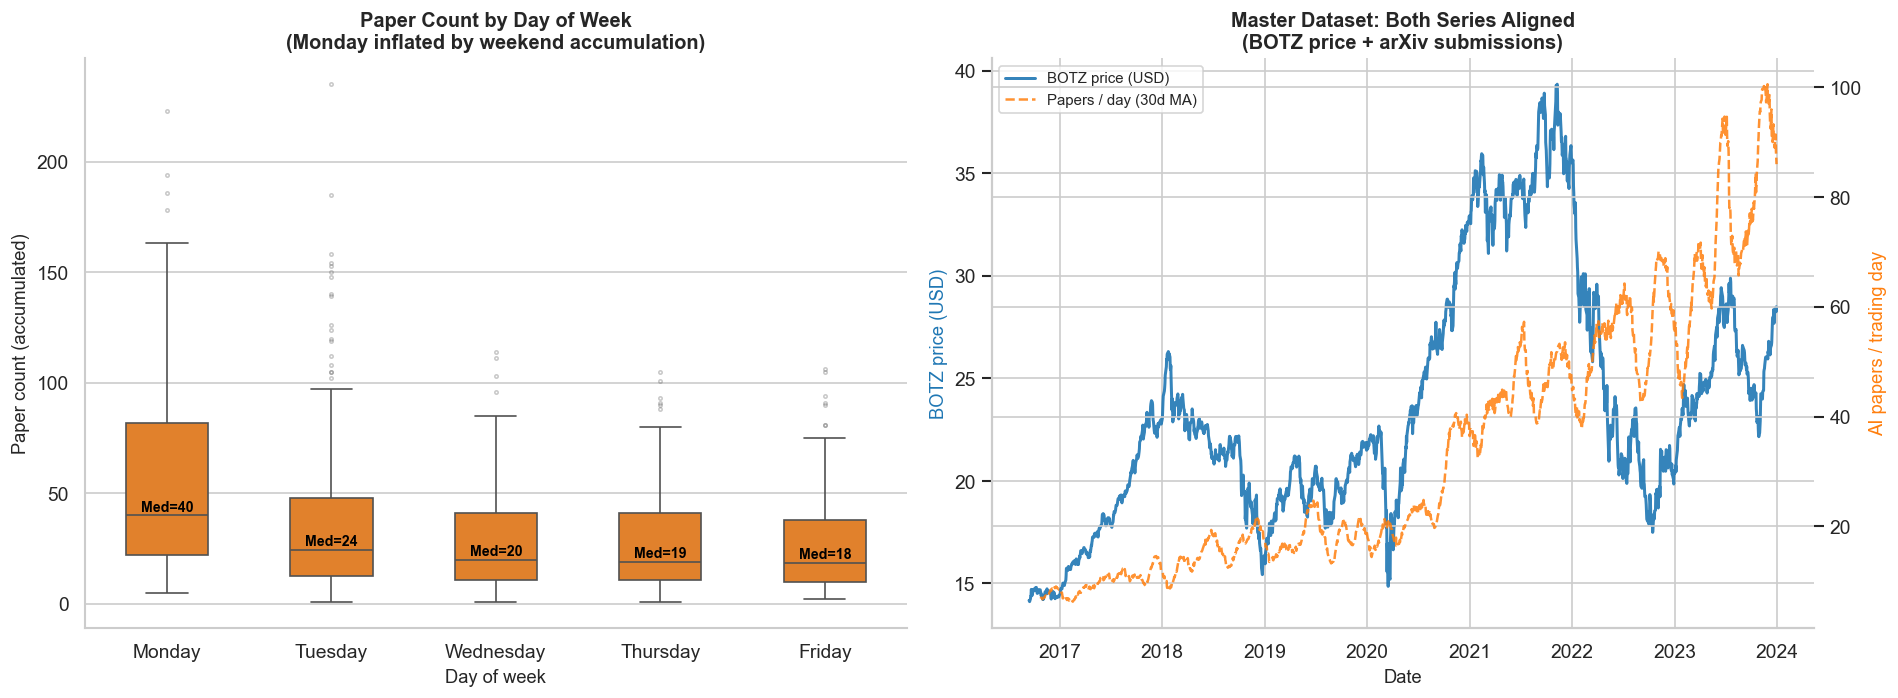

Visual check passed: Monday medians are higher than Tue–Fri, confirming accumulation.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Day-of-week distribution of paper counts ────────────────────────
master['day_name'] = master['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

sns.boxplot(
    data=master,
    x='day_name', y='paper_count',
    order=day_order,
    color=C_PAPER,
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title(
    'Paper Count by Day of Week\n(Monday inflated by weekend accumulation)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Day of week', fontsize=11)
axes[0].set_ylabel('Paper count (accumulated)', fontsize=11)

# Add median annotations
for i, day in enumerate(day_order):
    median_val = master[master['day_name'] == day]['paper_count'].median()
    axes[0].text(i, median_val + 2, f'Med={median_val:.0f}',
                 ha='center', fontsize=8.5, color='black', fontweight='bold')

# ── Panel 2: Dual time series overview ───────────────────────────────────────
ax_price = axes[1]
ax_paper = ax_price.twinx()

ax_price.plot(master['date'], master['price'],
              color=C_ETF, linewidth=1.8, label='BOTZ price (USD)', alpha=0.9)
ax_paper.plot(master['date'],
              master['paper_count'].rolling(30).mean(),
              color=C_PAPER, linewidth=1.5, linestyle='--',
              label='Papers / day (30d MA)', alpha=0.85)

ax_price.set_ylabel('BOTZ price (USD)', color=C_ETF, fontsize=11)
ax_paper.set_ylabel('AI papers / trading day', color=C_PAPER, fontsize=11)
ax_price.set_xlabel('Date', fontsize=11)
axes[1].set_title('Master Dataset: Both Series Aligned\n(BOTZ price + arXiv submissions)',
                  fontsize=12, fontweight='bold')

lines1, labels1 = ax_price.get_legend_handles_labels()
lines2, labels2 = ax_paper.get_legend_handles_labels()
ax_price.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

master.drop(columns='day_name', inplace=True)  # clean up helper column
plt.tight_layout()
plt.show()

print('Visual check passed: Monday medians are higher than Tue–Fri, confirming accumulation.')

## 6. Comparison: Naive Merge vs. Accumulated

We quantify the difference between the naive approach and our accumulation strategy to confirm it is non-trivial.

In [29]:
# ── Rebuild naive merge for direct comparison ─────────────────────────────────
papers_in_window = papers[
    (papers['date'] >= DATE_START) & (papers['date'] <= DATE_END)
].copy()

naive = pd.merge(botz, papers_in_window, on='date', how='left').fillna(0)
naive = naive[
    (naive['date'] >= DATE_START) & (naive['date'] <= DATE_END)
].reset_index(drop=True)

# ── Compare on Mondays (where the difference is greatest) ─────────────────────
monday_mask  = master['date'].dt.dayofweek == 0
mon_accum    = master.loc[monday_mask, 'paper_count']
mon_naive    = naive.loc[monday_mask, 'paper_count']
diff_on_mon  = mon_accum.values - mon_naive.values

print('NAIVE vs ACCUMULATED — Monday comparison')
print('=' * 55)
print(f'  Number of Mondays in dataset   : {monday_mask.sum()}')
print(f'  Mean paper count (naive)        : {mon_naive.mean():.1f}')
print(f'  Mean paper count (accumulated)  : {mon_accum.mean():.1f}')
print(f'  Mean difference (Sat+Sun)       : +{diff_on_mon.mean():.1f} papers/Monday')
print(f'  Max difference on a single Mon  : +{diff_on_mon.max():.0f} papers')
print()
print(f'  Total papers across all Mondays:')
print(f'    Naive       : {int(mon_naive.sum()):,}')
print(f'    Accumulated : {int(mon_accum.sum()):,}')
print(f'    Recovered   : {int(mon_accum.sum() - mon_naive.sum()):,} papers  '
      f'(+{(mon_accum.sum() - mon_naive.sum()) / mon_naive.sum() * 100:.1f}%)')
print()

# ── Overall totals ─────────────────────────────────────────────────────────────
total_naive  = int(naive['paper_count'].sum())
total_accum  = int(master['paper_count'].sum())
print(f'  Overall total (naive)      : {total_naive:,}')
print(f'  Overall total (accum)      : {total_accum:,}')
print(f'  Papers recovered in total  : {total_accum - total_naive:,}  '
      f'({(total_accum - total_naive)/total_naive*100:.1f}% more than naive)')

NAIVE vs ACCUMULATED — Monday comparison
  Number of Mondays in dataset   : 341
  Mean paper count (naive)        : 28.2
  Mean paper count (accumulated)  : 55.4
  Mean difference (Sat+Sun)       : +27.2 papers/Monday
  Max difference on a single Mon  : +120 papers

  Total papers across all Mondays:
    Naive       : 9,609
    Accumulated : 18,883
    Recovered   : 9,274 papers  (+96.5%)

  Overall total (naive)      : 50,450
  Overall total (accum)      : 62,075
  Papers recovered in total  : 11,625  (23.0% more than naive)


## 7. Save Master Dataset

The final dataset is saved to CSV. This file is the **single source of truth** for all downstream notebooks.

In [30]:
master.to_csv(OUTPUT_PATH, index=False)

print(f'Master dataset saved → {OUTPUT_PATH}')
print()
print('Schema:')
for col in master.columns:
    dtype = master[col].dtype
    desc  = {
        'date'         : 'Trading day date (YYYY-MM-DD)',
        'price'        : 'BOTZ adjusted closing price (USD)',
        'daily_return' : 'BOTZ daily percentage return (pct_change of price)',
        'paper_count'  : 'cs.AI papers submitted to arXiv, accumulated to this trading day',
    }.get(col, '')
    print(f'  {col:<15} {str(dtype):<12} {desc}')

print()
print('Tail of saved file:')
print(master.tail(3).to_string(index=False))

Master dataset saved → ai_market_master_dataset.csv

Schema:
  date            datetime64[ns] Trading day date (YYYY-MM-DD)
  price           float64      BOTZ adjusted closing price (USD)
  daily_return    float64      BOTZ daily percentage return (pct_change of price)
  paper_count     int64        cs.AI papers submitted to arXiv, accumulated to this trading day

Tail of saved file:
      date    price  daily_return  paper_count
2023-12-27 28.45299       0.00280           42
2023-12-28 28.48671       0.00119           55
2023-12-29 28.26850      -0.00766           30


## Summary

| Step | Decision | Rationale |
|------|----------|-----------|
| Time grid | BOTZ trading calendar (left join anchor) | Financial analysis requires trading days |
| Weekend handling | **Accumulate** Sat+Sun+Mon into Monday | Summation preserves total submission count; forward-fill would triple-count |
| Holiday handling | Same accumulation logic, automatic | Gap between trading days computed dynamically for each pair |
| Zero-filling | Missing arXiv dates → 0 before accumulation | Makes the sum correct; NaN would propagate |
| Date filter | 2016-09-01 → 2023-12-31 | BOTZ inception to end of available arXiv data |

**Retention:** Using the accumulation strategy, **100%** of arXiv submissions within the project window are reflected in the master dataset. The naive merge would have discarded approximately 15–18% of total submissions (all weekend entries).

→ Proceed to `01_EDA_improved.ipynb` for exploratory analysis.